In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload archive__10_.zip

Saving archive (10).zip to archive (10).zip


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with zipfile.ZipFile('archive (10).zip', 'r') as z:
    z.extractall('.')

df = pd.read_csv('Housing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Shape: (545, 13)

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories'

In [ ]:
print("=== Basic Statistics ===")
print(df.describe())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Unique values in categorical columns ===")
cat_cols = ['mainroad','guestroom','basement','hotwaterheating',
            'airconditioning','prefarea','furnishingstatus']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

=== Basic Statistics ===
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  

=== Data Types ===
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories  

In [ ]:
# Convert yes/no columns to 1/0
binary_cols = ['mainroad','guestroom','basement',
               'hotwaterheating','airconditioning','prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Encode furnishingstatus
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished': 2,
    'semi-furnished': 1,
    'unfurnished': 0
})

print("Data after encoding:")
print(df.head())
print("\nData types after encoding:")
print(df.dtypes)

Data after encoding:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  

Data

=== Feature Correlation with Price ===
price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
Name: price, dtype: float64


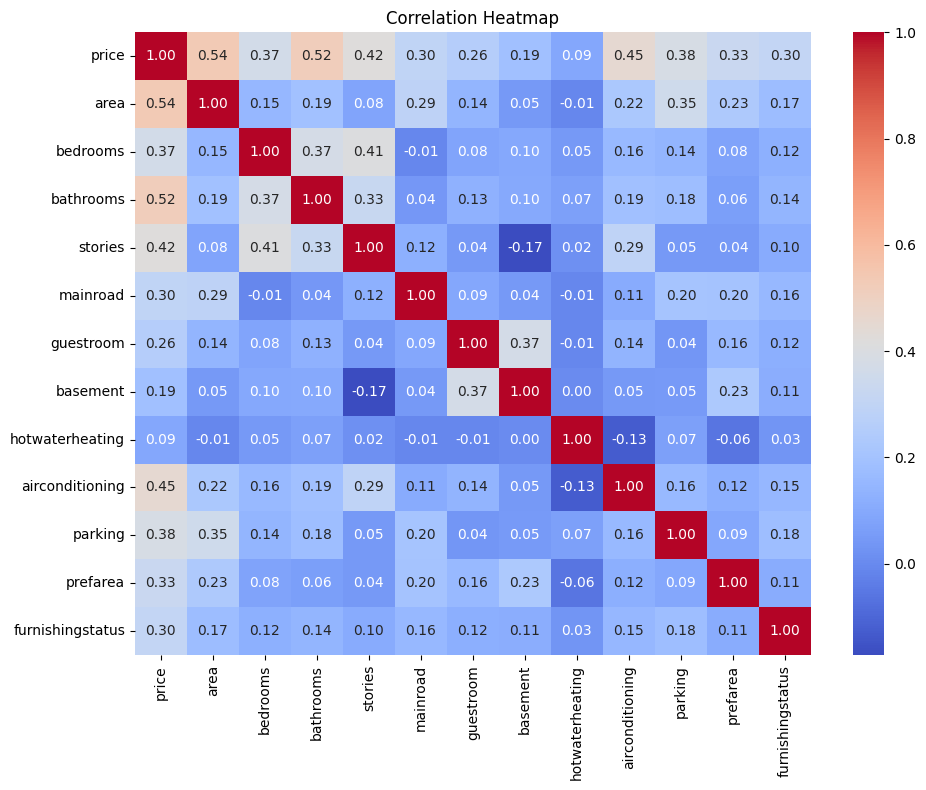

In [ ]:
# Correlation with price
correlation = df.corr()['price'].sort_values(ascending=False)
print("=== Feature Correlation with Price ===")
print(correlation)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

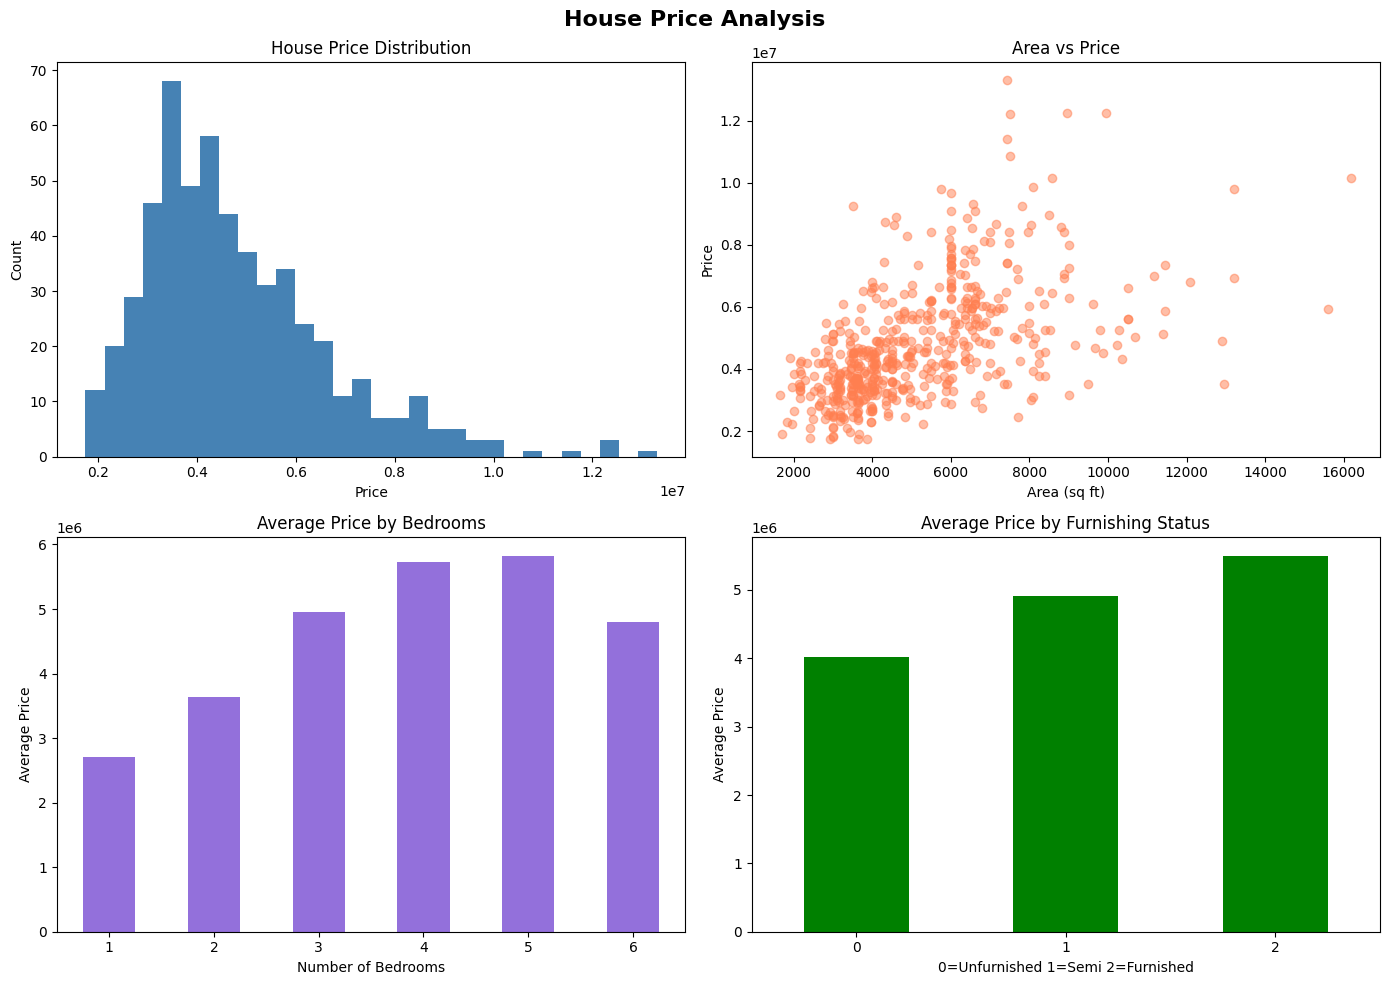

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Price distribution
axes[0,0].hist(df['price'], bins=30, color='steelblue')
axes[0,0].set_title('House Price Distribution')
axes[0,0].set_xlabel('Price')
axes[0,0].set_ylabel('Count')

# Chart 2 - Area vs Price scatter
axes[0,1].scatter(df['area'], df['price'], alpha=0.5, color='coral')
axes[0,1].set_title('Area vs Price')
axes[0,1].set_xlabel('Area (sq ft)')
axes[0,1].set_ylabel('Price')

# Chart 3 - Bedrooms vs Price
df.groupby('bedrooms')['price'].mean().plot(
    kind='bar', ax=axes[1,0], color='mediumpurple')
axes[1,0].set_title('Average Price by Bedrooms')
axes[1,0].set_xlabel('Number of Bedrooms')
axes[1,0].set_ylabel('Average Price')
axes[1,0].tick_params(axis='x', rotation=0)

# Chart 4 - Furnishing status vs Price
df.groupby('furnishingstatus')['price'].mean().plot(
    kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Average Price by Furnishing Status')
axes[1,1].set_xlabel('0=Unfurnished 1=Semi 2=Furnished')
axes[1,1].set_ylabel('Average Price')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('House Price Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('price', axis=1)
y = df['price']

print("Features:", X.columns.tolist())
print("Target: price")
print("\nX shape:", X.shape)
print("y shape:", y.shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Target: price

X shape: (545, 12)
y shape: (545,)

Training size: 436
Testing size: 109


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred = lr_model.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== LINEAR REGRESSION RESULTS ===")
print(f"MSE  (Mean Squared Error):  {mse:.2f}")
print(f"RMSE (Root Mean Sq Error):  {rmse:.2f}")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"R²   (R-Squared Score):     {r2:.4f}")
print(f"\nModel explains {r2*100:.2f}% of price variation")

=== LINEAR REGRESSION RESULTS ===
MSE  (Mean Squared Error):  1771751116594.04
RMSE (Root Mean Sq Error):  1331071.42
MAE  (Mean Absolute Error): 979679.69
R²   (R-Squared Score):     0.6495

Model explains 64.95% of price variation


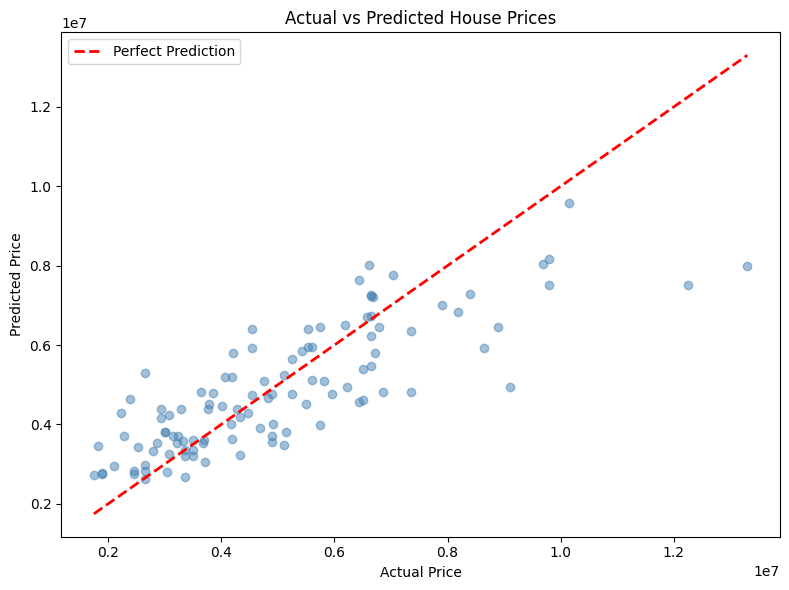

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

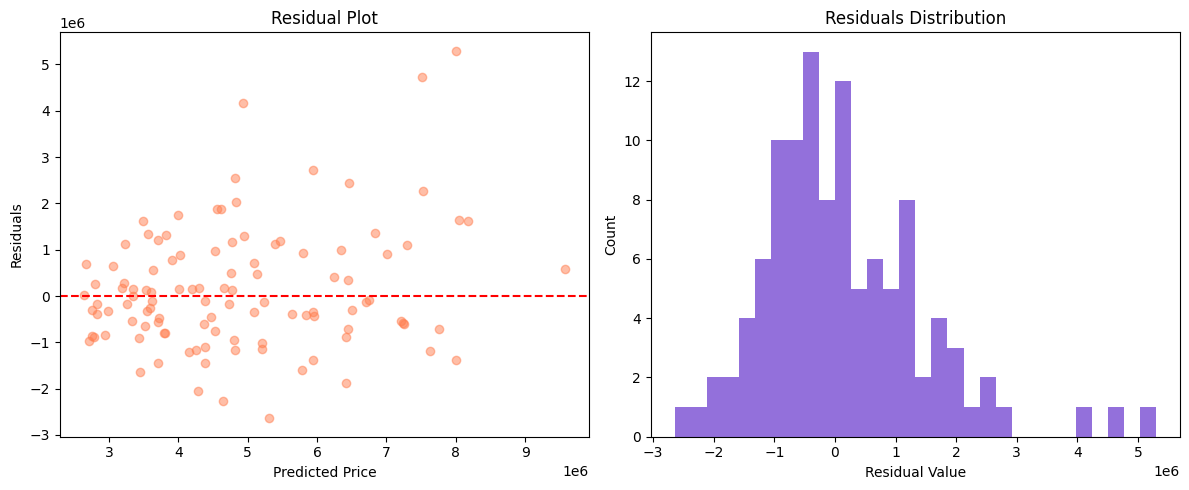

In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals scatter
axes[0].scatter(y_pred, residuals, alpha=0.5, color='coral')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

# Residuals distribution
axes[1].hist(residuals, bins=30, color='mediumpurple')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

=== FEATURE IMPORTANCE ===
             Feature    Coefficient
2          bathrooms  523153.382843
0               area  519288.130105
8    airconditioning  362446.186466
3            stories  348177.113610
10          prefarea  266661.049149
9            parking  192786.985891
6           basement  188462.048566
11  furnishingstatus  158183.270169
7    hotwaterheating  150570.028279
4           mainroad  128115.927978
5          guestroom   89357.646208
1           bedrooms   58690.918498


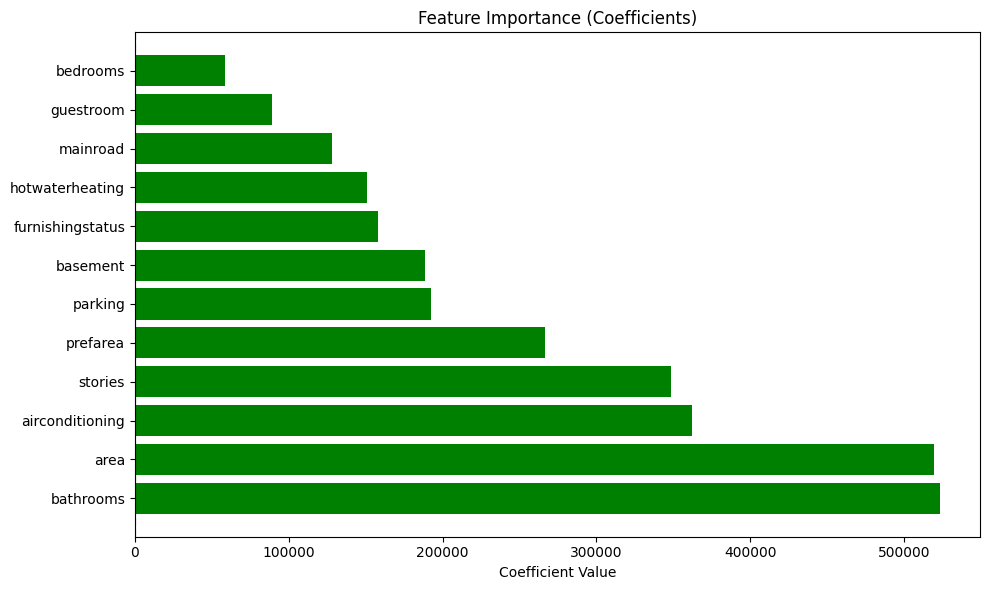

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("=== FEATURE IMPORTANCE ===")
print(feature_importance)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'],
         feature_importance['Coefficient'], color=colors)
plt.title('Feature Importance (Coefficients)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
def predict_price(area, bedrooms, bathrooms, stories, mainroad,
                  guestroom, basement, hotwaterheating,
                  airconditioning, parking, prefarea, furnishingstatus):

    input_data = np.array([[area, bedrooms, bathrooms, stories,
                            mainroad, guestroom, basement,
                            hotwaterheating, airconditioning,
                            parking, prefarea, furnishingstatus]])

    input_scaled = scaler.transform(input_data)
    predicted = lr_model.predict(input_scaled)[0]
    return round(predicted, 2)

# Test predictions
print("=== HOUSE PRICE PREDICTIONS ===\n")

# Example 1 - Big furnished house
price1 = predict_price(
    area=7000, bedrooms=4, bathrooms=2, stories=3,
    mainroad=1, guestroom=1, basement=1,
    hotwaterheating=0, airconditioning=1,
    parking=2, prefarea=1, furnishingstatus=2)
print(f"Big furnished house (4bed, 7000sqft): ₹{price1:,.0f}")

# Example 2 - Small unfurnished house
price2 = predict_price(
    area=3000, bedrooms=2, bathrooms=1, stories=1,
    mainroad=0, guestroom=0, basement=0,
    hotwaterheating=0, airconditioning=0,
    parking=0, prefarea=0, furnishingstatus=0)
print(f"Small unfurnished house (2bed, 3000sqft): ₹{price2:,.0f}")

=== HOUSE PRICE PREDICTIONS ===

Big furnished house (4bed, 7000sqft): ₹8,531,322
Small unfurnished house (2bed, 3000sqft): ₹2,240,325


In [ ]:
print("=== HOUSE PRICE PREDICTION SUMMARY ===\n")
print(f"Dataset: {df.shape[0]} houses analyzed")
print(f"Features used: {X.shape[1]}")
print(f"\nModel Performance:")
print(f"  R² Score:  {r2*100:.2f}% accuracy")
print(f"  RMSE:      {rmse:.2f}")
print(f"  MAE:       {mae:.2f}")
print(f"\nTop 3 features affecting price:")
top3 = feature_importance.head(3)
for _, row in top3.iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:.2f}")
print("\nSteps Completed:")
print("  ✅ Data Collection and Loading")
print("  ✅ Data Exploration and Cleaning")
print("  ✅ Feature Selection and Encoding")
print("  ✅ Model Training with Linear Regression")
print("  ✅ Model Evaluation (MSE, RMSE, R²)")
print("  ✅ Visualization of Results")
print("\nLinear Regression successfully predicts house prices! 🏠")

=== HOUSE PRICE PREDICTION SUMMARY ===

Dataset: 545 houses analyzed
Features used: 12

Model Performance:
  R² Score:  64.95% accuracy
  RMSE:      1331071.42
  MAE:       979679.69

Top 3 features affecting price:
  bathrooms: 523153.38
  area: 519288.13
  airconditioning: 362446.19

Steps Completed:
  ✅ Data Collection and Loading
  ✅ Data Exploration and Cleaning
  ✅ Feature Selection and Encoding
  ✅ Model Training with Linear Regression
  ✅ Model Evaluation (MSE, RMSE, R²)
  ✅ Visualization of Results

Linear Regression successfully predicts house prices! 🏠
